## **Configuraciones Iniciales**

### **1. Definir puerto de datos**
El ESP32 S3, trae dos puertos usb-c, primer paso es identificar cual de los dos puertos es solo de alimentacion y cual es el de alimentacion + transmision de datos serial

Conectamos a la PC y vemos cual de los puertos es la que hace que windows reconozca un nuevo dispositivo

En mi caso, el **puerto de la derecha**

En Administrador de dispositivos de windows, vemos como reconoce windows a la placa, buscamos en la seccion **Puertos (COM y LPT).**

**USB-Enhanced-SERIAL CH343 (COM7)**

Eso significa que:

- el cable sí sirve para datos;
- el driver CH343 ya está instalado correctamente;
- la placa está siendo reconocida;
-  el USB-C de la derecha es el que debemos usar para programar la ESP32-S3 por ahora.

### **2. Descargar el IDE de Arduino**

El firewall muestra una alarma pero ponemos permitir

Aceptamos todas las instalaciones y esperamos que se instalen todas las cosas del IDE de Arduino

### **3. Descargar e instalar ESP32**

Desde Boards Manager / Gestor de placas, en el buscador escribimos esp32

**SOLO INSTALAMOS: esp32 by Espressif Systems**

La version actual me marca como 3.3.11, pero el kit que compre trae documentacion para las versiones 3.0.x y una rama de 2.0.x

- **La version que instalare es 3.0.7**, y no le damos a update para mantenernos en esta version

### **4. Seleccion de placa**

Windows habia detectado la placa como COM7

En select board, seleccionamos y luego empezamos a jugar con los parametros

En el cuadro Search board de la izquierda escribimos:

**ESP32S3 Dev Module**

Seleccionamos solo **ESP32S3 Dev Module**

- No selecciones ESP32S3 Dev Module Octal (WROOM2). Queremos el ESP32S3 Dev Module normal.

### **5. Antes de subir el primer programa**

en Tools / Herramientas y revisemos estos valores

**Configuramos así:**

- Board: ESP32S3 Dev Module
- Port: COM7
- Flash Size: 8MB (64Mb)
- PSRAM: OPI PSRAM
- USB CDC On Boot: Disabled porque estamos usando el puerto CH343 externo
- Partition Scheme: una opción de 8MB, idealmente Default 8MB with spiffs
- Upload Speed: puedes dejar el valor predeterminado por ahora

La combinación de 8 MB Flash + OPI PSRAM coincide con este tipo de kit

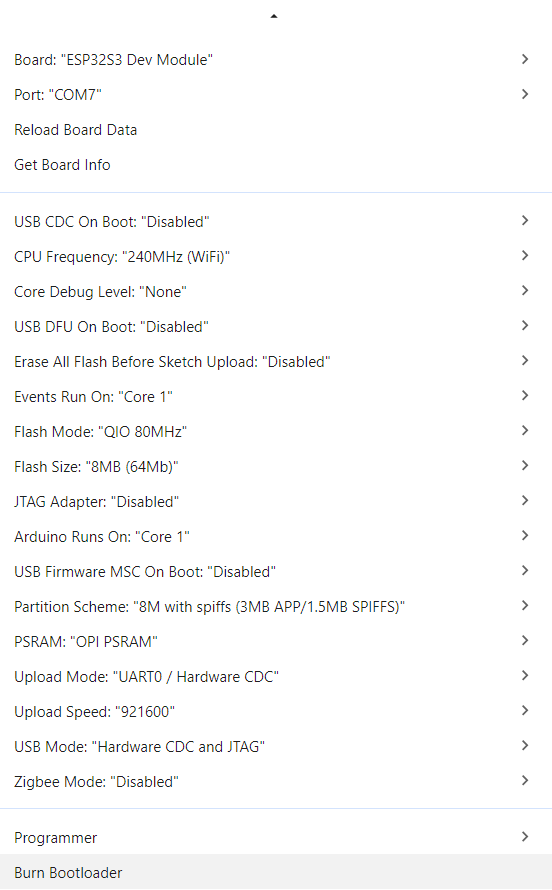

### **5. Primer programa**

```bash
void setup() {
  Serial.begin(115200);
  delay(1000);

  Serial.println("================================");
  Serial.println("Hola desde mi ESP32-S3 Freenove!");
  Serial.println("La placa funciona correctamente.");
  Serial.println("================================");
}

void loop() {
  Serial.println("ESP32-S3 funcionando...");
  delay(1000);
}
```

**No cargamos de una, primero verificamos**

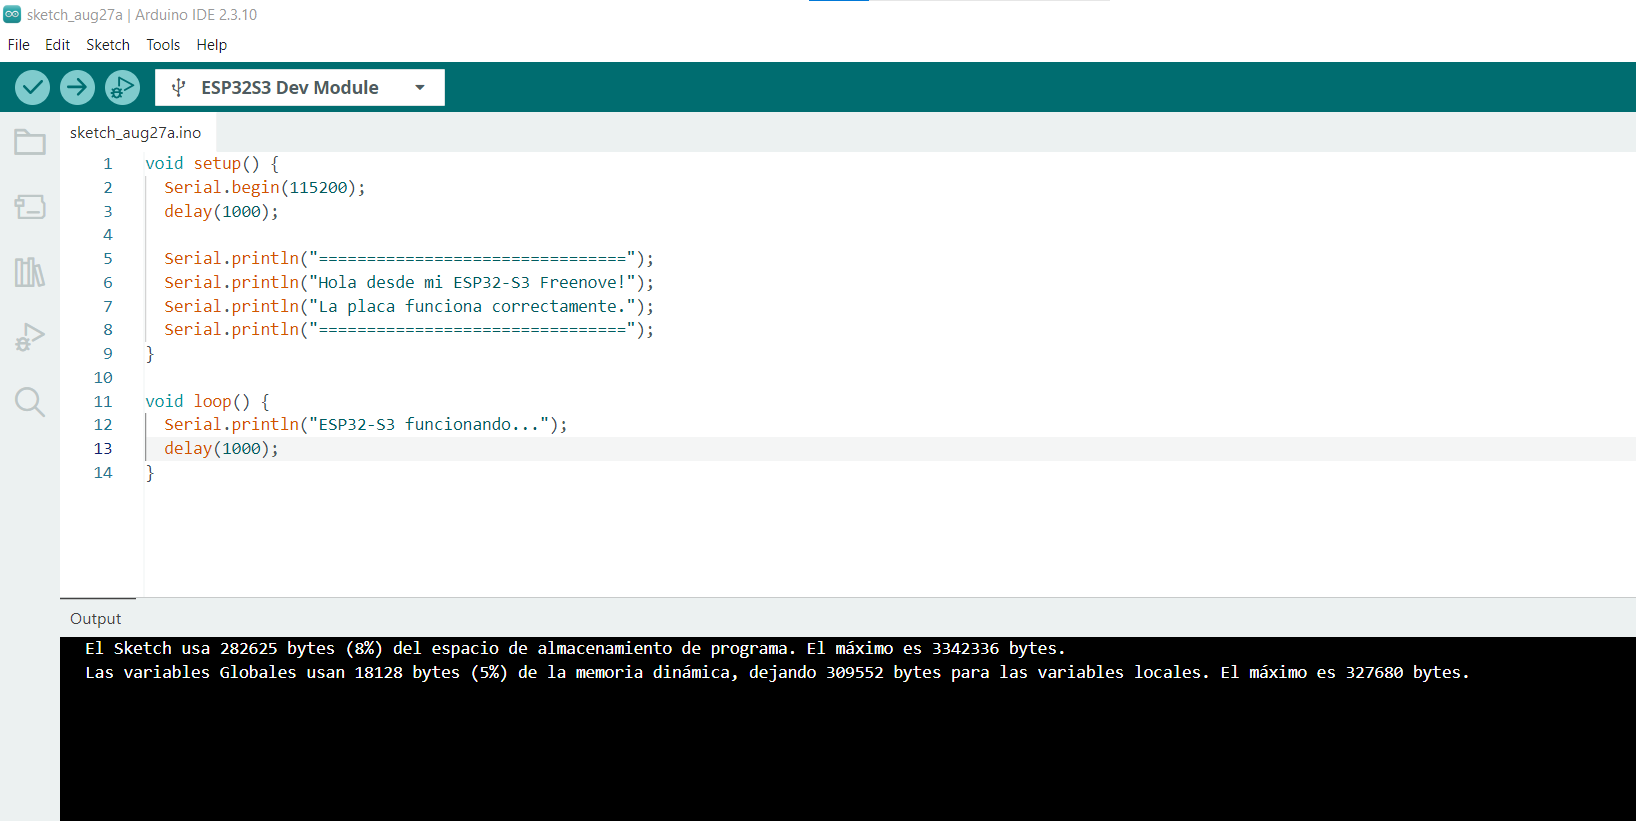

La compilación fue exitosa. No hay errores. ✅

La parte inferior confirma:

- El Sketch usa 282625 bytes (8%)
- Las variables globales usan 18128 bytes (5%)

**Eso significa que Arduino pudo compilar correctamente el programa para tu ESP32-S3.**

Ahora viene la primera escritura real en el microcontrolador.

**Cargar el programa al ESP32-S3**

Asegúrate de que:

- ESP32 sigue conectado por el USB-C derecho.
- Arriba sigue diciendo ESP32S3 Dev Module.
- Seguimos utilizando COM7.

Ahora pulsa el botón → que está arriba a la izquierda, justo al lado de ✓.

Ese es **Upload / Subir.**

### **6. Verificar en el monior serial**

Ahora vamos a comprobar que el programa realmente se está ejecutando:

- Arriba a la derecha de Arduino IDE busca el icono de Monitor Serie.
- Ábrelo.
- Configura la velocidad en 115200 baud.
- Deberías empezar a ver:
```bash
Hola desde mi ESP32-S3 Freenove!
La placa funciona correctamente.
ESP32-S3 funcionando...
ESP32-S3 funcionando...
ESP32-S3 funcionando...
```
Si el Monitor Serie queda vacío, pulsa una vez el botón RESET/RST de la placa y observa qué aparece.

**¿Importa la velocidad en que actualiza los datos el monitor en serie?**

El programa que ingresamos tiene: 

```bash
Serial.begin(115200);
```

Cuando puse otra velocidad, por ejemplo 9600 o 57600, el ESP32 seguía enviando los bits a 115200, pero Arduino intentaba interpretarlos con otra velocidad. El resultado son caracteres raros como ����.


**Con todo esto, confirmamos:**

- todo está funcionando bien: Windows reconoce la placa por COM7, 
- Arduino compila, el programa se carga correctamente y 
- el ESP32 ejecuta el código y se comunica con el PC.

Primera prueba del ESP32 S3, completada con exito
